# 05. Adjusted Sensitivity Analysis

This notebook evaluates whether the estimated Diabetes Peer Support effect remains similar after adjusting for baseline member characteristics.

The main questions are:

1. Does the peer-support treatment effect remain positive after adjustment?
2. Is the adjusted estimate directionally similar to the unadjusted intent-to-treat result?
3. Are baseline factors such as prior compliance, SDOH risk, health literacy, and baseline engagement associated with diabetes testing compliance?

Important caution:

The randomized intent-to-treat result from Notebook 02 remains the main A/B testing result.

This notebook is a robustness check. Adjustment can improve precision and account for minor baseline imbalance, but it should not replace the randomized comparison.

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

## 2. Load Dataset

In [2]:
# Define the project-relative path to the synthetic A/B testing dataset
DATA_PATH = Path("../data/raw/mock_diabetes_peer_support_ab_test.csv")

# Load the generated dataset into a pandas DataFrame
df = pd.read_csv(DATA_PATH)

# Confirm the number of rows and columns
df.shape

(4000, 33)

## 3. Preview Dataset

In [3]:
# Preview the first few rows to confirm the dataset loaded correctly
df.head()

,member_id,age,gender,region,plan_type,target_population_flag,diabetes_severity_score,chronic_condition_count,baseline_engagement_score,health_literacy_score,...,peer_leader_supervised,contact_frequency_per_month,assigned_diabetes_tests_count,a1c_test_completed,kidney_screening_completed,eye_exam_completed,diabetes_tests_completed_count,diabetes_testing_compliance_rate,diabetes_testing_compliant,program_data_quality_issue
0,1,64,Male,Urban,Medicaid,1,0.263,1,0.866,0.349,...,0,1,3,1,1,1,3,1.000,1,0
1,2,69,Male,Rural,D-SNP,1,0.361,5,0.253,0.533,...,1,2,3,1,0,0,1,0.333,0,0
2,3,74,Female,Urban,Medicare Advantage,1,0.598,2,0.483,0.189,...,0,1,3,1,0,0,1,0.333,0,0
3,4,72,Male,Urban,Medicare Advantage,1,0.189,4,0.377,0.811,...,1,2,3,0,1,1,2,0.667,0,0
4,5,42,Female,Suburban,Medicaid,1,0.759,3,0.541,0.606,...,0,1,3,1,1,0,2,0.667,0,0


In [4]:
# Review column names, data types, and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   member_id                         4000 non-null   int64  
 1   age                               4000 non-null   int64  
 2   gender                            4000 non-null   str    
 3   region                            4000 non-null   str    
 4   plan_type                         4000 non-null   str    
 5   target_population_flag            4000 non-null   int64  
 6   diabetes_severity_score           4000 non-null   float64
 7   chronic_condition_count           4000 non-null   int64  
 8   baseline_engagement_score         3749 non-null   float64
 9   health_literacy_score             3706 non-null   float64
 10  prior_testing_compliance_rate     4000 non-null   float64
 11  sdoh_risk_score                   4000 non-null   float64
 12  food_insecurity  

In [5]:
# Confirm randomized experiment group counts
df["experiment_group"].value_counts()

experiment_group
Diabetes Peer Support    2078
Standard Outreach        1922
Name: count, dtype: int64

## 4. Treatment Indicator

In [6]:
# Create a binary treatment indicator for regression modeling
df["peer_support_treatment"] = np.where(
    df["experiment_group"] == "Diabetes Peer Support",
    1,
    0
)

# Confirm the treatment indicator matches the original experiment group
pd.crosstab(df["experiment_group"], df["peer_support_treatment"])

peer_support_treatment,0,1
experiment_group,,
Diabetes Peer Support,0,2078
Standard Outreach,1922,0


## 5. Review Missingness

The synthetic dataset intentionally includes structured missingness in selected baseline fields.

For adjusted modeling, we need a clear missing-data strategy.

In this notebook, we use median imputation for numeric baseline variables. This keeps the full randomized sample in the model while avoiding listwise deletion.

## 6. Define Adjustment Variables

In [7]:
# Define baseline variables used for adjusted sensitivity analysis
adjustment_vars = [
    "age",
    "diabetes_severity_score",
    "chronic_condition_count",
    "baseline_engagement_score",
    "health_literacy_score",
    "prior_testing_compliance_rate",
    "sdoh_risk_score",
    "food_insecurity",
    "transportation_barrier",
    "financial_barrier",
    "housing_instability",
    "pcp_attributed_24mo"
]

# Check missingness in model variables before imputation
df[adjustment_vars].isna().mean().sort_values(ascending=False)

health_literacy_score            0.07350
baseline_engagement_score        0.06275
diabetes_severity_score          0.00000
age                              0.00000
chronic_condition_count          0.00000
prior_testing_compliance_rate    0.00000
sdoh_risk_score                  0.00000
food_insecurity                  0.00000
transportation_barrier           0.00000
financial_barrier                0.00000
housing_instability              0.00000
pcp_attributed_24mo              0.00000
dtype: float64

## 7. Median Imputation

In [8]:
# Create a modeling copy so the original dataset remains unchanged
model_df = df.copy()

# Impute missing numeric baseline variables using the median
for col in adjustment_vars:
    model_df[col] = model_df[col].fillna(model_df[col].median())

# Confirm missingness has been handled for model variables
model_df[adjustment_vars].isna().sum()

age                              0
diabetes_severity_score          0
chronic_condition_count          0
baseline_engagement_score        0
health_literacy_score            0
prior_testing_compliance_rate    0
sdoh_risk_score                  0
food_insecurity                  0
transportation_barrier           0
financial_barrier                0
housing_instability              0
pcp_attributed_24mo              0
dtype: int64

Median imputation is used here as a simple sensitivity-analysis strategy to preserve the full randomized sample.

Because missingness is structured in the synthetic data, median imputation should not be treated as a perfect missing-data solution. A more advanced analysis could compare complete-case models, missingness-indicator models, or multiple imputation.

For this portfolio notebook, the goal is to check whether the treatment estimate remains directionally stable after baseline adjustment.

This imputation approach is used for a simple robustness check, not as a claim that median imputation is the best missing-data method.

## 8. Unadjusted OLS Model

First, we fit a simple unadjusted model using average diabetes testing compliance rate as the outcome.

This should align closely with the raw intent-to-treat difference from Notebook 02.

In [9]:
# Fit an unadjusted OLS model for average diabetes testing compliance rate
unadjusted_ols = smf.ols(
    formula="diabetes_testing_compliance_rate ~ peer_support_treatment",
    data=model_df
).fit(cov_type="HC3")

# Display the regression summary
unadjusted_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                   OLS Regression Results                                   
============================================================================================
Dep. Variable:     diabetes_testing_compliance_rate   R-squared:                       0.004
Model:                                          OLS   Adj. R-squared:                  0.003
Method:                               Least Squares   F-statistic:                     14.60
Date:                              Tue, 09 Jun 2026   Prob (F-statistic):           0.000135
Time:                                      23:59:24   Log-Likelihood:                -354.40
No. Observations:                              4000   AIC:                             712.8
Df Residuals:                                  3998   BIC:                             725.4
Df Model:                                         1                                         
Covariance Type:                                HC3                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0.7125      0.006    116.036      0.000       0.700       0.725
peer_support_treatment     0.0320      0.008      3.821      0.000       0.016       0.048
==============================================================================
Omnibus:                      256.581   Durbin-Watson:                   2.007
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              301.756
Skew:                          -0.663   Prob(JB):                     2.98e-66
Kurtosis:                       2.773   Cond. No.                         2.67
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

## 9. Adjusted OLS Model

Next, we adjust for baseline member characteristics.

The treatment coefficient estimates the average difference in diabetes testing compliance rate between Diabetes Peer Support and Standard Outreach after controlling for baseline traits.


In [10]:
# Build the adjusted OLS formula using baseline covariates
adjusted_ols_formula = """
diabetes_testing_compliance_rate ~ peer_support_treatment
+ age
+ diabetes_severity_score
+ chronic_condition_count
+ baseline_engagement_score
+ health_literacy_score
+ prior_testing_compliance_rate
+ sdoh_risk_score
+ food_insecurity
+ transportation_barrier
+ financial_barrier
+ housing_instability
+ pcp_attributed_24mo
"""

# Fit the adjusted OLS model
adjusted_ols = smf.ols(
    formula=adjusted_ols_formula,
    data=model_df
).fit(cov_type="HC3")

# Display the adjusted model summary
adjusted_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                   OLS Regression Results                                   
============================================================================================
Dep. Variable:     diabetes_testing_compliance_rate   R-squared:                       0.137
Model:                                          OLS   Adj. R-squared:                  0.134
Method:                               Least Squares   F-statistic:                     51.98
Date:                              Tue, 09 Jun 2026   Prob (F-statistic):          3.38e-125
Time:                                      23:59:24   Log-Likelihood:                -66.671
No. Observations:                              4000   AIC:                             161.3
Df Residuals:                                  3986   BIC:                             249.5
Df Model:                                        13                                         
Covariance Type:                                HC3                                         
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                         0.4575      0.027     16.862      0.000       0.404       0.511
peer_support_treatment            0.0272      0.008      3.463      0.001       0.012       0.043
age                               0.0004      0.000      1.404      0.160      -0.000       0.001
diabetes_severity_score          -0.0060      0.020     -0.293      0.769      -0.046       0.034
chronic_condition_count          -0.0040      0.002     -1.677      0.093      -0.009       0.001
baseline_engagement_score         0.2325      0.020     11.681      0.000       0.194       0.272
health_literacy_score             0.1565      0.020      7.863      0.000       0.118       0.196
prior_testing_compliance_rate     0.0861      0.023      3.790      0.000       0.042       0.131
sdoh_risk_score                  -0.1407      0.055     -2.559      0.011      -0.249      -0.033
food_insecurity                  -0.0068      0.018     -0.385      0.700      -0.042       0.028
transportation_barrier           -0.0171      0.018     -0.949      0.343      -0.052       0.018
financial_barrier                -0.0162      0.015     -1.054      0.292      -0.046       0.014
housing_instability               0.0091      0.013      0.719      0.472      -0.016       0.034
pcp_attributed_24mo               0.0927      0.009     10.874      0.000       0.076       0.109
==============================================================================
Omnibus:                      184.100   Durbin-Watson:                   2.016
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              209.347
Skew:                          -0.558   Prob(JB):                     3.47e-46
Kurtosis:                       2.897   Cond. No.                         957.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

## 10. OLS Treatment Effect Comparison

In [11]:
# Extract treatment effect estimates from unadjusted and adjusted OLS models
ols_effect_comparison = pd.DataFrame({
    "model": ["Unadjusted OLS", "Adjusted OLS"],
    "treatment_coefficient": [
        unadjusted_ols.params["peer_support_treatment"],
        adjusted_ols.params["peer_support_treatment"]
    ],
    "p_value": [
        unadjusted_ols.pvalues["peer_support_treatment"],
        adjusted_ols.pvalues["peer_support_treatment"]
    ],
    "ci_lower": [
        unadjusted_ols.conf_int().loc["peer_support_treatment", 0],
        adjusted_ols.conf_int().loc["peer_support_treatment", 0]
    ],
    "ci_upper": [
        unadjusted_ols.conf_int().loc["peer_support_treatment", 1],
        adjusted_ols.conf_int().loc["peer_support_treatment", 1]
    ]
})

# Convert coefficients from proportions to percentage points
ols_effect_comparison["treatment_effect_pp"] = (
    ols_effect_comparison["treatment_coefficient"] * 100
)

ols_effect_comparison["ci_lower_pp"] = (
    ols_effect_comparison["ci_lower"] * 100
)

ols_effect_comparison["ci_upper_pp"] = (
    ols_effect_comparison["ci_upper"] * 100
)

# Round values for reporting
ols_effect_comparison = ols_effect_comparison.round(4)

ols_effect_comparison

,model,treatment_coefficient,p_value,ci_lower,ci_upper,treatment_effect_pp,ci_lower_pp,ci_upper_pp
0,Unadjusted OLS,0.0320,0.0001,0.0156,0.0485,3.2027,1.5598,4.8456
1,Adjusted OLS,0.0272,0.0005,0.0118,0.0425,2.7168,1.1792,4.2544


## 11. OLS Effect Visualization

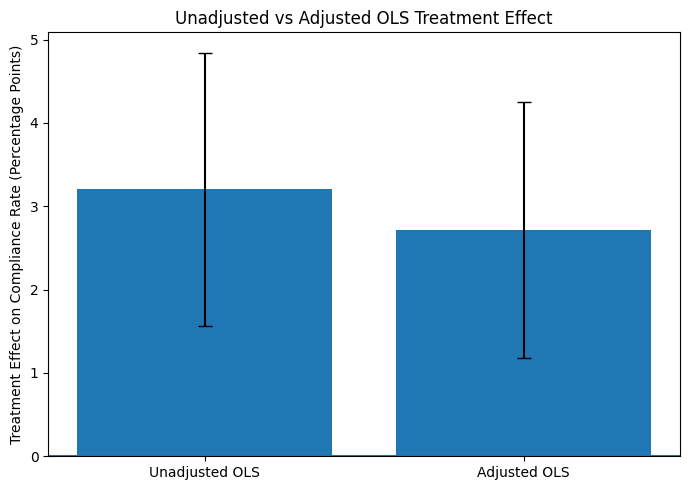

In [12]:
# Visualize unadjusted and adjusted OLS treatment effects with 95% confidence intervals
plot_df = ols_effect_comparison.copy()

yerr_lower = plot_df["treatment_effect_pp"] - plot_df["ci_lower_pp"]
yerr_upper = plot_df["ci_upper_pp"] - plot_df["treatment_effect_pp"]

plt.figure(figsize=(7, 5))

plt.bar(
    plot_df["model"],
    plot_df["treatment_effect_pp"],
    yerr=[yerr_lower, yerr_upper],
    capsize=5
)

plt.title("Unadjusted vs Adjusted OLS Treatment Effect")
plt.ylabel("Treatment Effect on Compliance Rate (Percentage Points)")
plt.axhline(0)
plt.tight_layout()
plt.show()

## 12. Unadjusted Logistic Regression

The binary compliance outcome is modeled using logistic regression.

First, we fit an unadjusted logistic regression model with only the treatment indicator.

This provides a regression-based version of the unadjusted binary compliance comparison from Notebook 02.

In [13]:
# Fit an unadjusted logistic regression model for binary compliance
unadjusted_logit = smf.logit(
    formula="diabetes_testing_compliant ~ peer_support_treatment",
    data=model_df
).fit(cov_type="HC3")

# Display the unadjusted logistic regression summary
unadjusted_logit.summary()

Optimization terminated successfully.
         Current function value: 0.671946
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                               Logit Regression Results                               
======================================================================================
Dep. Variable:     diabetes_testing_compliant   No. Observations:                 4000
Model:                                  Logit   Df Residuals:                     3998
Method:                                   MLE   Df Model:                            1
Date:                        Tue, 09 Jun 2026   Pseudo R-squ.:                0.001734
Time:                                23:59:25   Log-Likelihood:                -2687.8
converged:                               True   LL-Null:                       -2692.5
Covariance Type:                          HC3   LLR p-value:                  0.002247
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0.5081      0.047    -10.787      0.000      -0.600      -0.416
peer_support_treatment     0.1976      0.065      3.053      0.002       0.071       0.324
==========================================================================================
"""

## 13. Adjusted Logistic Regression

In [14]:
# Build the adjusted logistic regression formula using baseline covariates
adjusted_logit_formula = """
diabetes_testing_compliant ~ peer_support_treatment
+ age
+ diabetes_severity_score
+ chronic_condition_count
+ baseline_engagement_score
+ health_literacy_score
+ prior_testing_compliance_rate
+ sdoh_risk_score
+ food_insecurity
+ transportation_barrier
+ financial_barrier
+ housing_instability
+ pcp_attributed_24mo
"""

# Fit the adjusted logistic regression model
adjusted_logit = smf.logit(
    formula=adjusted_logit_formula,
    data=model_df
).fit(cov_type="HC3")

# Display the adjusted logistic regression summary
adjusted_logit.summary()

Optimization terminated successfully.
         Current function value: 0.621355
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                               Logit Regression Results                               
======================================================================================
Dep. Variable:     diabetes_testing_compliant   No. Observations:                 4000
Model:                                  Logit   Df Residuals:                     3986
Method:                                   MLE   Df Model:                           13
Date:                        Tue, 09 Jun 2026   Pseudo R-squ.:                 0.07689
Time:                                23:59:25   Log-Likelihood:                -2485.4
converged:                               True   LL-Null:                       -2692.5
Covariance Type:                          HC3   LLR p-value:                 2.388e-80
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept                        -2.4054      0.240    -10.010      0.000      -2.876      -1.934
peer_support_treatment            0.1826      0.068      2.678      0.007       0.049       0.316
age                               0.0006      0.002      0.290      0.772      -0.004       0.005
diabetes_severity_score          -0.1277      0.176     -0.725      0.468      -0.473       0.217
chronic_condition_count          -0.0229      0.021     -1.100      0.271      -0.064       0.018
baseline_engagement_score         1.6471      0.173      9.544      0.000       1.309       1.985
health_literacy_score             1.2538      0.175      7.161      0.000       0.911       1.597
prior_testing_compliance_rate     0.7586      0.199      3.822      0.000       0.370       1.148
sdoh_risk_score                  -1.0031      0.468     -2.145      0.032      -1.920      -0.087
food_insecurity                   0.0032      0.153      0.021      0.983      -0.296       0.302
transportation_barrier           -0.1433      0.155     -0.923      0.356      -0.448       0.161
financial_barrier                -0.1202      0.130     -0.922      0.356      -0.376       0.135
housing_instability               0.0790      0.106      0.745      0.456      -0.129       0.287
pcp_attributed_24mo               0.6451      0.073      8.863      0.000       0.502       0.788
=================================================================================================
"""

## 14. Logistic Treatment Effect Comparison

In [15]:
# Extract log-odds treatment estimates from logistic models
logit_effect_comparison = pd.DataFrame({
    "model": ["Unadjusted Logistic", "Adjusted Logistic"],
    "log_odds_coefficient": [
        unadjusted_logit.params["peer_support_treatment"],
        adjusted_logit.params["peer_support_treatment"]
    ],
    "p_value": [
        unadjusted_logit.pvalues["peer_support_treatment"],
        adjusted_logit.pvalues["peer_support_treatment"]
    ],
    "ci_lower_log_odds": [
        unadjusted_logit.conf_int().loc["peer_support_treatment", 0],
        adjusted_logit.conf_int().loc["peer_support_treatment", 0]
    ],
    "ci_upper_log_odds": [
        unadjusted_logit.conf_int().loc["peer_support_treatment", 1],
        adjusted_logit.conf_int().loc["peer_support_treatment", 1]
    ]
})

# Convert log-odds coefficients into odds ratios
logit_effect_comparison["odds_ratio"] = np.exp(
    logit_effect_comparison["log_odds_coefficient"]
)

logit_effect_comparison["ci_lower_odds_ratio"] = np.exp(
    logit_effect_comparison["ci_lower_log_odds"]
)

logit_effect_comparison["ci_upper_odds_ratio"] = np.exp(
    logit_effect_comparison["ci_upper_log_odds"]
)

# Round values for reporting
logit_effect_comparison = logit_effect_comparison.round(4)

logit_effect_comparison

,model,log_odds_coefficient,p_value,ci_lower_log_odds,ci_upper_log_odds,odds_ratio,ci_lower_odds_ratio,ci_upper_odds_ratio
0,Unadjusted Logistic,0.1976,0.0023,0.0707,0.3245,1.2185,1.0733,1.3833
1,Adjusted Logistic,0.1826,0.0074,0.0490,0.3162,1.2003,1.0502,1.3720


## 15. Logistic Odds Ratio Visualization

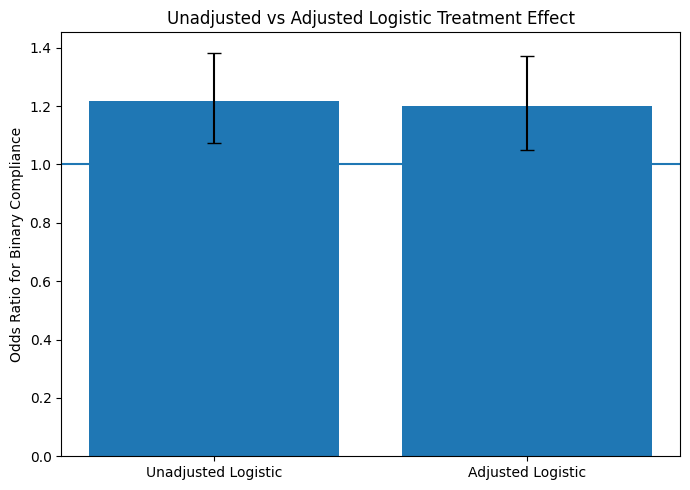

In [16]:
# Visualize unadjusted and adjusted logistic odds ratios with 95% confidence intervals
plot_df = logit_effect_comparison.copy()

yerr_lower = plot_df["odds_ratio"] - plot_df["ci_lower_odds_ratio"]
yerr_upper = plot_df["ci_upper_odds_ratio"] - plot_df["odds_ratio"]

plt.figure(figsize=(7, 5))

plt.bar(
    plot_df["model"],
    plot_df["odds_ratio"],
    yerr=[yerr_lower, yerr_upper],
    capsize=5
)

plt.title("Unadjusted vs Adjusted Logistic Treatment Effect")
plt.ylabel("Odds Ratio for Binary Compliance")
plt.axhline(1)
plt.tight_layout()
plt.show()

## 16. Baseline Predictor Review 

In addition to the treatment effect, the adjusted model helps identify which baseline characteristics are associated with diabetes testing compliance.

These associations should not be interpreted as causal effects. They are useful for understanding member risk patterns and future targeting.

## 17. Adjusted OLS Baseline Coefficients

In [17]:
# Extract adjusted OLS coefficients for baseline predictor interpretation
ols_coefficients = pd.DataFrame({
    "variable": adjusted_ols.params.index,
    "coefficient": adjusted_ols.params.values,
    "p_value": adjusted_ols.pvalues.values
})

# Remove the intercept for cleaner interpretation
ols_coefficients = ols_coefficients[
    ols_coefficients["variable"] != "Intercept"
].copy()

# Convert compliance-rate coefficients to percentage points
ols_coefficients["coefficient_pp"] = ols_coefficients["coefficient"] * 100

# Sort by absolute coefficient size
ols_coefficients["abs_coefficient_pp"] = ols_coefficients["coefficient_pp"].abs()

ols_coefficients = (
    ols_coefficients
    .sort_values("abs_coefficient_pp", ascending=False)
    .round(4)
)

ols_coefficients

,variable,coefficient,p_value,coefficient_pp,abs_coefficient_pp
5,baseline_engagement_score,0.2325,0.0000,23.2523,23.2523
6,health_literacy_score,0.1565,0.0000,15.6540,15.6540
8,sdoh_risk_score,-0.1407,0.0105,-14.0745,14.0745
13,pcp_attributed_24mo,0.0927,0.0000,9.2662,9.2662
7,prior_testing_compliance_rate,0.0861,0.0002,8.6090,8.6090
1,peer_support_treatment,0.0272,0.0005,2.7168,2.7168
10,transportation_barrier,-0.0171,0.3427,-1.7111,1.7111
11,financial_barrier,-0.0162,0.2920,-1.6227,1.6227
12,housing_instability,0.0091,0.4723,0.9120,0.9120
9,food_insecurity,-0.0068,0.7004,-0.6815,0.6815


## 18. Sensitivity Findings

The adjusted sensitivity analysis showed that the Diabetes Peer Support estimate remained positive after controlling for observed baseline characteristics.

For the average diabetes testing compliance rate:

- Unadjusted OLS treatment effect: approximately **3.2 percentage points**
- Adjusted OLS treatment effect: approximately **2.7 percentage points**
- Adjusted 95% confidence interval: approximately **1.2 to 4.2 percentage points**
- Adjusted p-value: approximately **0.0005**

The adjusted estimate remained positive and statistically significant, supporting robustness of the observed A/B result.

For the binary compliance outcome:

- Unadjusted logistic odds ratio: approximately **1.22**
- Adjusted logistic odds ratio: approximately **1.20**
- Adjusted 95% confidence interval: approximately **1.05 to 1.37**
- Adjusted p-value: approximately **0.0074**

This suggests that the positive Diabetes Peer Support result was reasonably stable after adjustment for observed baseline characteristics.

Important interpretation:

This notebook is a sensitivity analysis, not the primary causal analysis. The main evidence still comes from the randomized intent-to-treat comparison in Notebook 02.

Because the adjustment variables are observed baseline characteristics, this analysis can check whether the result is robust to measured baseline differences. It cannot fully address unobserved confounding or prove that every modeled baseline predictor has a causal effect.

## 19. Business Interpretation

The adjusted sensitivity analysis helps confirm whether the observed Diabetes Peer Support improvement is reasonably stable after accounting for baseline member differences.

If the adjusted result remains positive, this strengthens confidence that the program effect is not simply due to observable baseline differences.

If prior testing compliance, baseline engagement, or SDOH risk are strongly associated with the outcome, these variables may help future outreach teams prioritize members who need additional support.

However, this notebook should not be framed as a machine learning prediction notebook. Its purpose is robustness testing and interpretation, not building a deployment-ready predictive model.

## 20. Summary

This notebook evaluated whether the Diabetes Peer Support result remained stable after adjusting for baseline member characteristics.

Key takeaways:

1. A binary treatment indicator was created for regression modeling.
2. Structured missingness in baseline variables was handled using median imputation.
3. An unadjusted OLS model estimated the raw treatment effect on average compliance rate.
4. An adjusted OLS model estimated the treatment effect after controlling for baseline traits.
5. An unadjusted logistic regression model evaluated the binary compliance outcome.
6. An adjusted logistic regression model estimated the treatment odds ratio after baseline adjustment.
7. Baseline predictors were reviewed to understand member characteristics associated with compliance.
8. The adjusted analysis was interpreted as a sensitivity check, not a replacement for the intent-to-treat A/B result.

The main randomized evidence remains the overall intent-to-treat comparison from Notebook 02. This notebook supports robustness, precision, and business interpretation.